# Nuclear vs Wind/Solar: cleanliness rebuttal

This notebook tests the claim that **nuclear electricity is cleaner than wind or solar**.

It has three parts:

1. **Carbon-only** lifecycle greenhouse-gas emissions (gCO2e/kWh) with an uncertainty simulation. This is the most common metric behind the claim, and it is enough to reject the broad version.
2. **Beyond carbon** — a twelve-metric cleanliness profile across ten technologies, with explicit uncertainty ranges, policy scenarios, Monte Carlo propagation and rank-stability diagnostics. This shows that *which* technology is “cleanest” depends on what you weight.
3. **Region & deployment context** — multi-region counterfactuals, region-aware financing (cost of capital), and geography/grid/deployment-year marginal abatement. A clean technology's value is contextual, not absolute.

Metric definitions live in [`../DATA_DICTIONARY.md`](../DATA_DICTIONARY.md); data provenance in [`../data/data_sources.md`](../data/data_sources.md); the method summary in [`../docs/methods_note.md`](../docs/methods_note.md).

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from energy_cleanliness.data import load_lifecycle_data
from energy_cleanliness.analysis import (
    compare_to_baseline,
    simulate_uncertainty,
    estimate_pairwise_probabilities,
)
from energy_cleanliness.multimetric import (
    METRIC_UNITS,
    load_multimetric_profile,
    higher_is_better_set,
    to_wide,
)
from energy_cleanliness.scenarios import SCENARIOS
from energy_cleanliness.cleanliness_index import (
    monte_carlo_cleanliness,
    pareto_frontier,
)
from energy_cleanliness.reporting import build_report, validate_report
from energy_cleanliness.regions import run_region_scenarios
from energy_cleanliness.financing import DEFAULT_ENVIRONMENTS, lcoe_table, wacc_sensitivity
from energy_cleanliness.geography import (
    load_grid_intensity,
    trajectory_table,
    abatement_table,
)
from energy_cleanliness.plotting import (
    plot_lifecycle_ranges,
    plot_probability_matrix,
    plot_scenario_scores,
    plot_rank_stability,
)

reports_dir = PROJECT_ROOT / 'reports'
figures_dir = reports_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
SEED = 42
SAMPLES = 2000

## 1. Carbon-only lifecycle emissions

If the claim were broadly true, nuclear should have lower lifecycle emissions than wind and solar under the same source (IPCC AR5 Annex III).

In [2]:
data = load_lifecycle_data(PROJECT_ROOT / 'data' / 'lifecycle_emissions_ipcc_ar5.csv')
data[['technology', 'min_gco2e_kwh', 'median_gco2e_kwh', 'max_gco2e_kwh']]

,technology,min_gco2e_kwh,median_gco2e_kwh,max_gco2e_kwh
0,Wind onshore,7.0,11,56
1,Nuclear,3.7,12,110
2,Wind offshore,8.0,12,35
3,Solar PV rooftop,26.0,41,60
4,Solar PV utility,18.0,48,180


In [3]:
comparison = compare_to_baseline(data, baseline='Nuclear')
comparison[['technology', 'baseline_minus_other', 'interpretation']]

,technology,baseline_minus_other,interpretation
0,Solar PV rooftop,-29.0,Nuclear has a lower reported median lifecycle ...
1,Solar PV utility,-36.0,Nuclear has a lower reported median lifecycle ...
2,Wind offshore,0.0,Wind offshore and Nuclear have the same report...
3,Wind onshore,1.0,Wind onshore has a lower reported median lifec...


Onshore wind has a **lower** median than nuclear and offshore wind is tied, so the broad “cleaner than wind” claim already fails on its own preferred metric.

### Uncertainty simulation

The reported min / median / max are turned into a triangular proxy distribution to make the overlap visible. This is a sensitivity check, not a reconstruction of the literature distribution. Cell `(A, B)` is the estimated probability that A has lower lifecycle emissions than B.

In [4]:
samples = simulate_uncertainty(data, draws=50_000, seed=SEED)
probability_matrix = estimate_pairwise_probabilities(samples)
probability_matrix.round(3)

,Nuclear,Solar PV rooftop,Solar PV utility,Wind offshore,Wind onshore
Nuclear,NaN,0.556,0.824,0.188,0.290
Solar PV rooftop,0.444,NaN,0.870,0.003,0.108
Solar PV utility,0.176,0.130,NaN,0.004,0.032
Wind offshore,0.812,0.997,0.996,NaN,0.661
Wind onshore,0.710,0.892,0.968,0.339,NaN


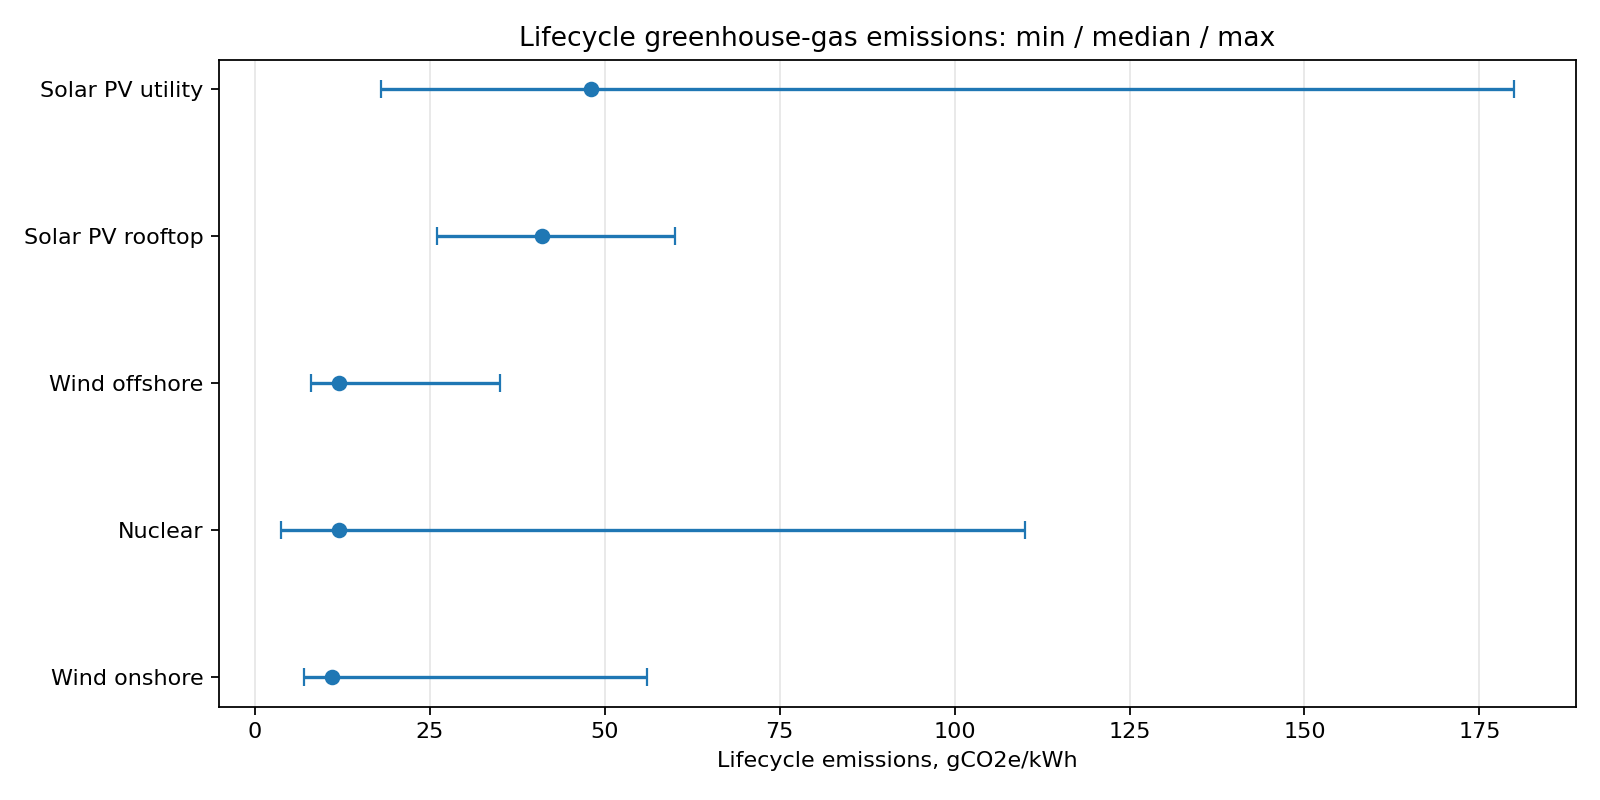

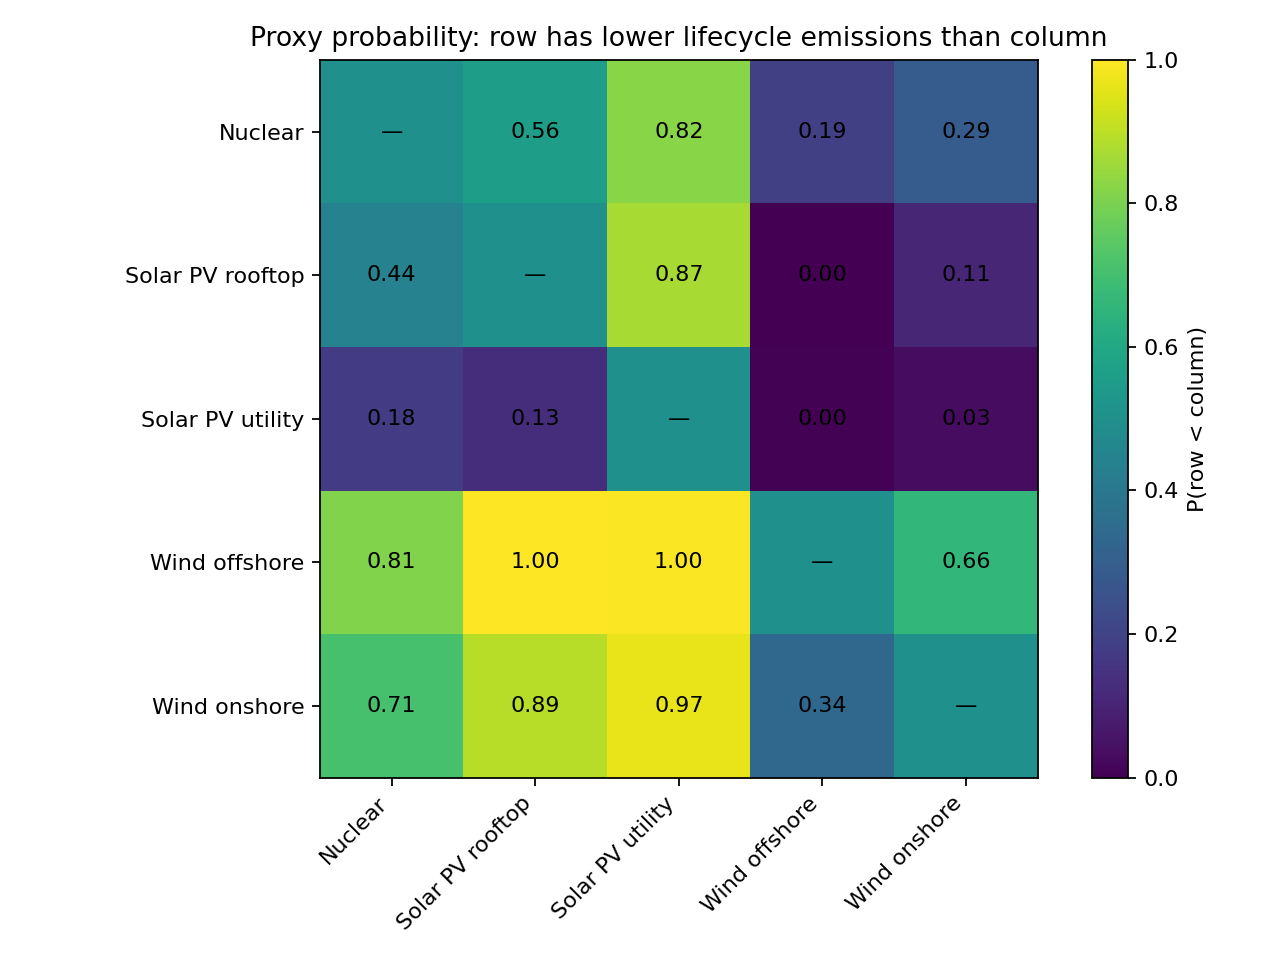

In [5]:
plot_lifecycle_ranges(data, reports_dir / 'lifecycle_ranges.png')
plot_probability_matrix(probability_matrix, reports_dir / 'probability_matrix.png')
display(Image(filename=str(reports_dir / 'lifecycle_ranges.png')))
display(Image(filename=str(reports_dir / 'probability_matrix.png')))

## 2. Beyond carbon — multi-metric cleanliness

“Clean” is undefined in the claim. We make it explicit with twelve metrics across **ten technologies** (the original five plus hydro, geothermal, biomass, gas with CCS and biomass with CCS). Each cell carries a `low / central / high` uncertainty range and a declared direction (`lower_better` or `higher_better`). The loader validates the schema and fails fast on misaligned columns or missing cells.

In [6]:
profile = load_multimetric_profile(PROJECT_ROOT / 'data' / 'multimetric_cleanliness_reference.csv')
higher = higher_is_better_set(profile)
wide = to_wide(profile, value='central')
print('technologies:', sorted(wide['technology']))
print('higher-is-better metrics:', sorted(higher))
profile.head(6)

technologies: ['Biomass', 'Biomass with CCS', 'Gas with CCS', 'Geothermal', 'Hydro', 'Nuclear', 'Solar PV rooftop', 'Solar PV utility', 'Wind offshore', 'Wind onshore']
higher-is-better metrics: ['capacity_factor', 'grid_integration']


,schema_version,technology,metric,unit,direction,low,central,high,year,source_id,notes
0,1.0,Nuclear,lifecycle_co2e,gco2e_kwh,lower_better,3.70,12.000,110.00,2014,ipcc_ar5,IPCC AR5 Annex III lifecycle median and range.
1,1.0,Nuclear,direct_deaths,deaths_per_twh,lower_better,0.01,0.030,0.07,2021,owid_deaths,Accident plus occupational deaths per TWh.
2,1.0,Nuclear,air_pollution_deaths,deaths_per_twh,lower_better,0.00,0.007,0.02,2021,owid_deaths,Near-zero combustion air pollution.
3,1.0,Nuclear,waste_persistence,index_0_15,lower_better,8.00,12.000,15.00,2022,unece_lca,Long-lived radioactive waste persistence index.
4,1.0,Nuclear,water_use,m3_mwh,lower_better,1.00,2.500,14.00,2022,unece_lca,Consumptive central; high reflects once-throug...
5,1.0,Nuclear,land_use,m2_mwh,lower_better,0.30,1.000,1.80,2022,luderer_land,Direct plus fuel-cycle land footprint.


In [7]:
# Best technology per metric, respecting each metric's direction.
best_by_metric = {}
for metric in METRIC_UNITS:
    if metric in higher:
        best_by_metric[metric] = wide.loc[wide[metric].idxmax(), 'technology']
    else:
        best_by_metric[metric] = wide.loc[wide[metric].idxmin(), 'technology']
pd.Series(best_by_metric, name='best_technology').to_frame()

,best_technology
lifecycle_co2e,Biomass with CCS
direct_deaths,Geothermal
air_pollution_deaths,Hydro
waste_persistence,Hydro
water_use,Solar PV rooftop
land_use,Solar PV utility
material_intensity,Wind onshore
construction_time,Solar PV rooftop
capacity_factor,Nuclear
grid_integration,Hydro


No single technology wins every metric. The **Pareto frontier** is the set that is never beaten on all metrics at once.

In [8]:
frontier = pareto_frontier(
    wide, metrics=list(METRIC_UNITS), minimize=False, higher_is_better=higher
)
list(frontier['technology'])

['Biomass',
 'Biomass with CCS',
 'Geothermal',
 'Hydro',
 'Nuclear',
 'Solar PV rooftop',
 'Solar PV utility',
 'Wind offshore',
 'Wind onshore']

### Policy scenarios with Monte Carlo uncertainty

A scenario is a set of metric weights encoding a *policy intent*. For each one we sample every metric from `triangular(low, central, high)`, normalise within the draw, weight and sum, then report the mean score, a 95% credible interval, and **rank stability** — how often each technology lands at rank 1.

In [9]:
scenario_results = {}
rows = []
for name, weights in SCENARIOS.items():
    mc = monte_carlo_cleanliness(profile, weights=weights, samples=SAMPLES, seed=SEED)
    scenario_results[name] = mc
    summary = mc['score_summary']
    stability = mc['rank_stability']
    leader = summary.iloc[0]
    p_rank1 = float(stability.loc[stability['technology'] == leader['technology'], 'p_top1'].iloc[0])
    rows.append({
        'scenario': name,
        'leader': leader['technology'],
        'leader_mean_score': round(float(leader['mean_score']), 3),
        'leader_P(rank1)': round(p_rank1, 2),
        'ranking': ' > '.join(summary['technology']),
    })
leaders = pd.DataFrame(rows)
leaders

,scenario,leader,leader_mean_score,leader_P(rank1),ranking
0,balanced,Wind onshore,0.779,0.55,Wind onshore > Geothermal > Solar PV utility >...
1,low_emissions_first,Wind onshore,0.664,0.60,Wind onshore > Geothermal > Wind offshore > So...
2,low_cost_first,Wind onshore,0.872,0.88,Wind onshore > Solar PV utility > Geothermal >...
3,high_reliability_first,Geothermal,0.816,0.93,Geothermal > Nuclear > Gas with CCS > Biomass ...


The leader **flips with the policy intent**: reliability-first favours dispatchable sources (geothermal, then nuclear), while cost-first and emissions-first favour wind, solar and geothermal. That is the whole point — there is no single “cleanest” technology.

Compare two contrasting scenarios visually — scores with 95% intervals, and rank stability.

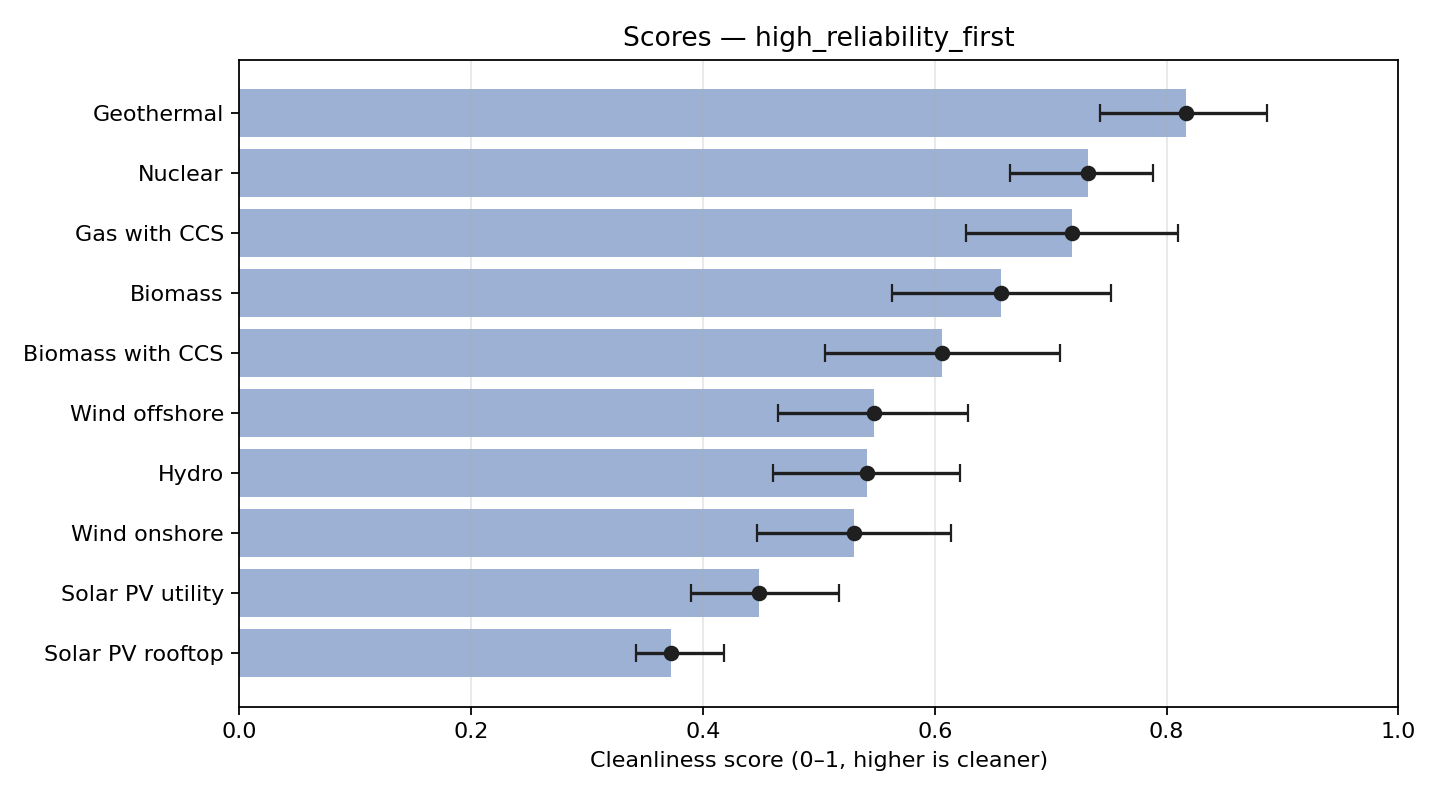

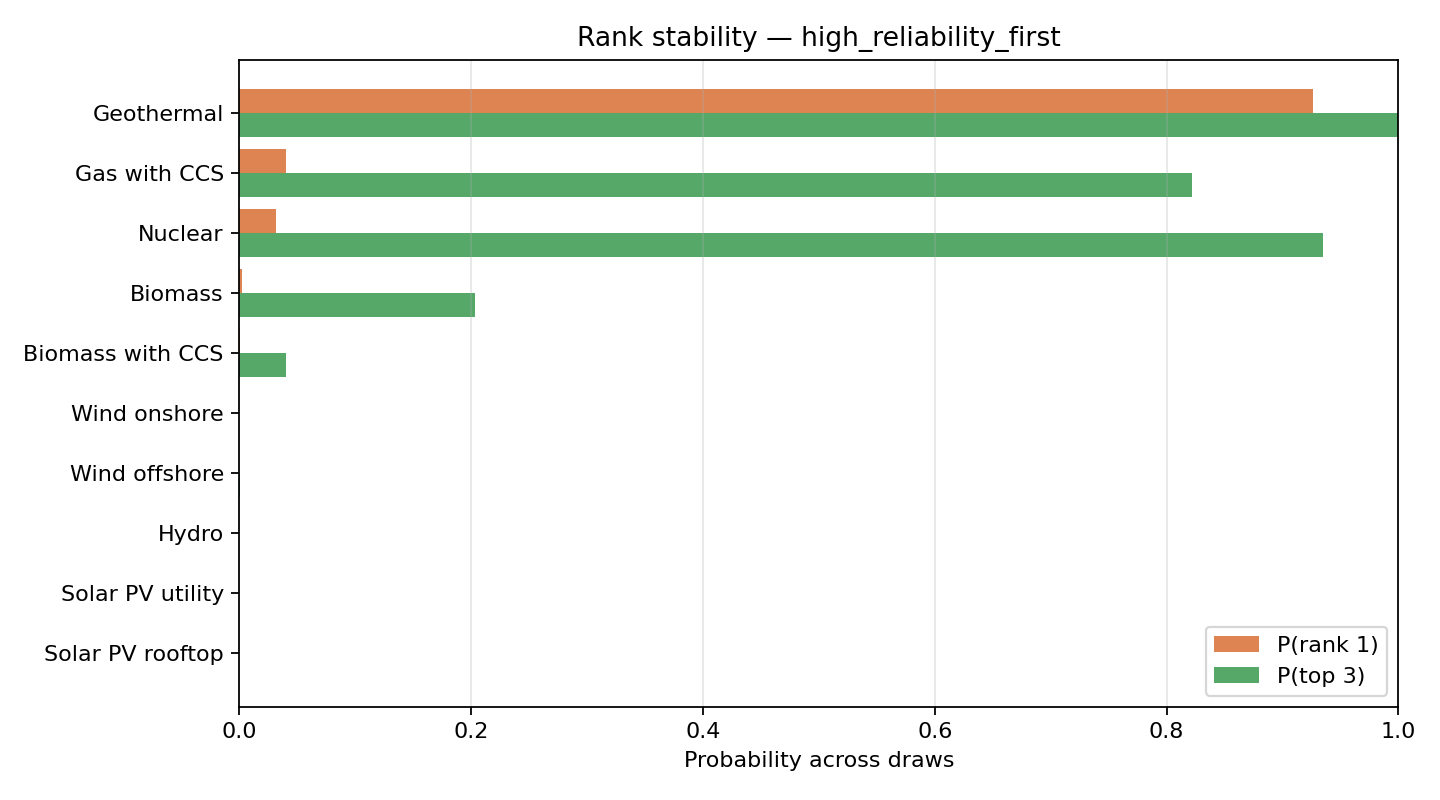

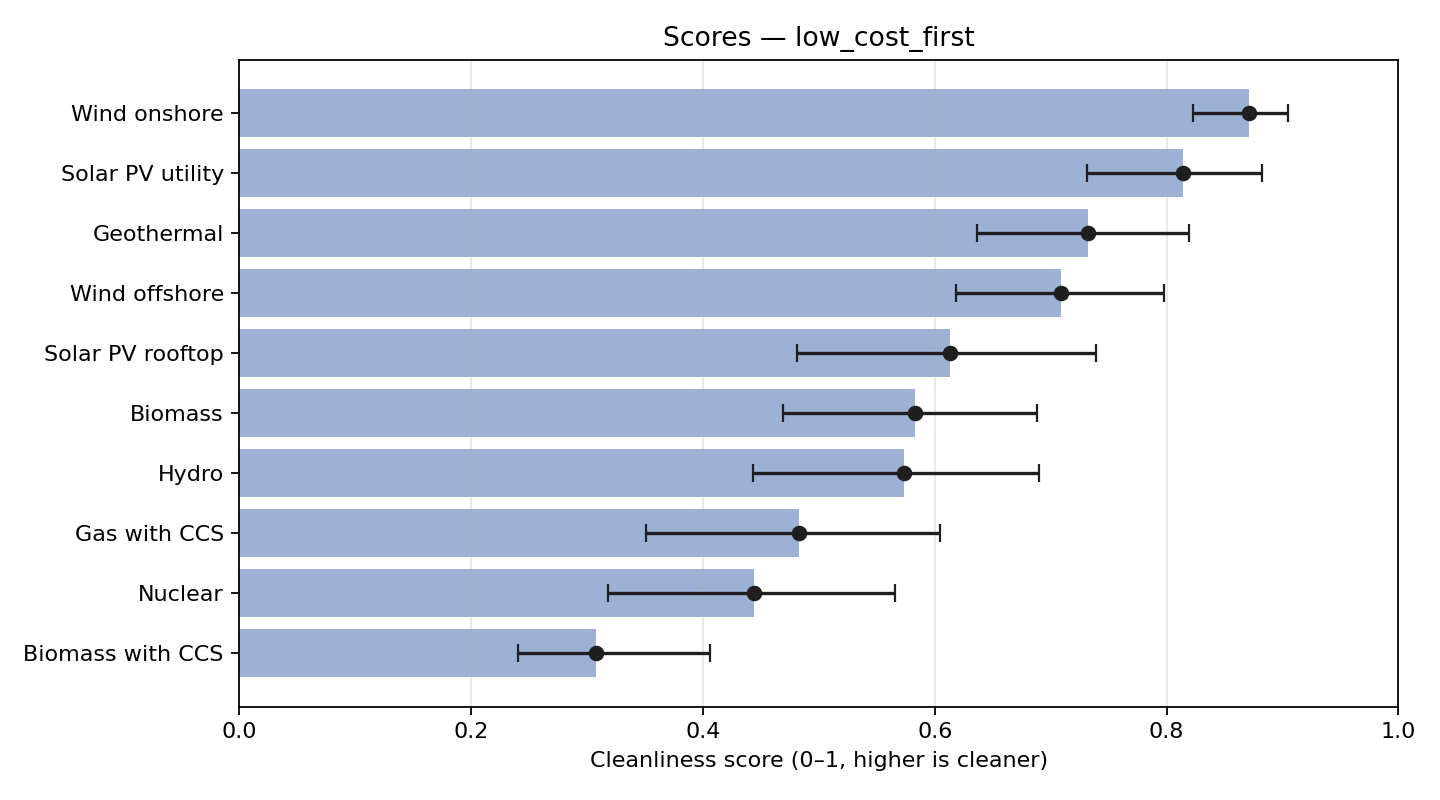

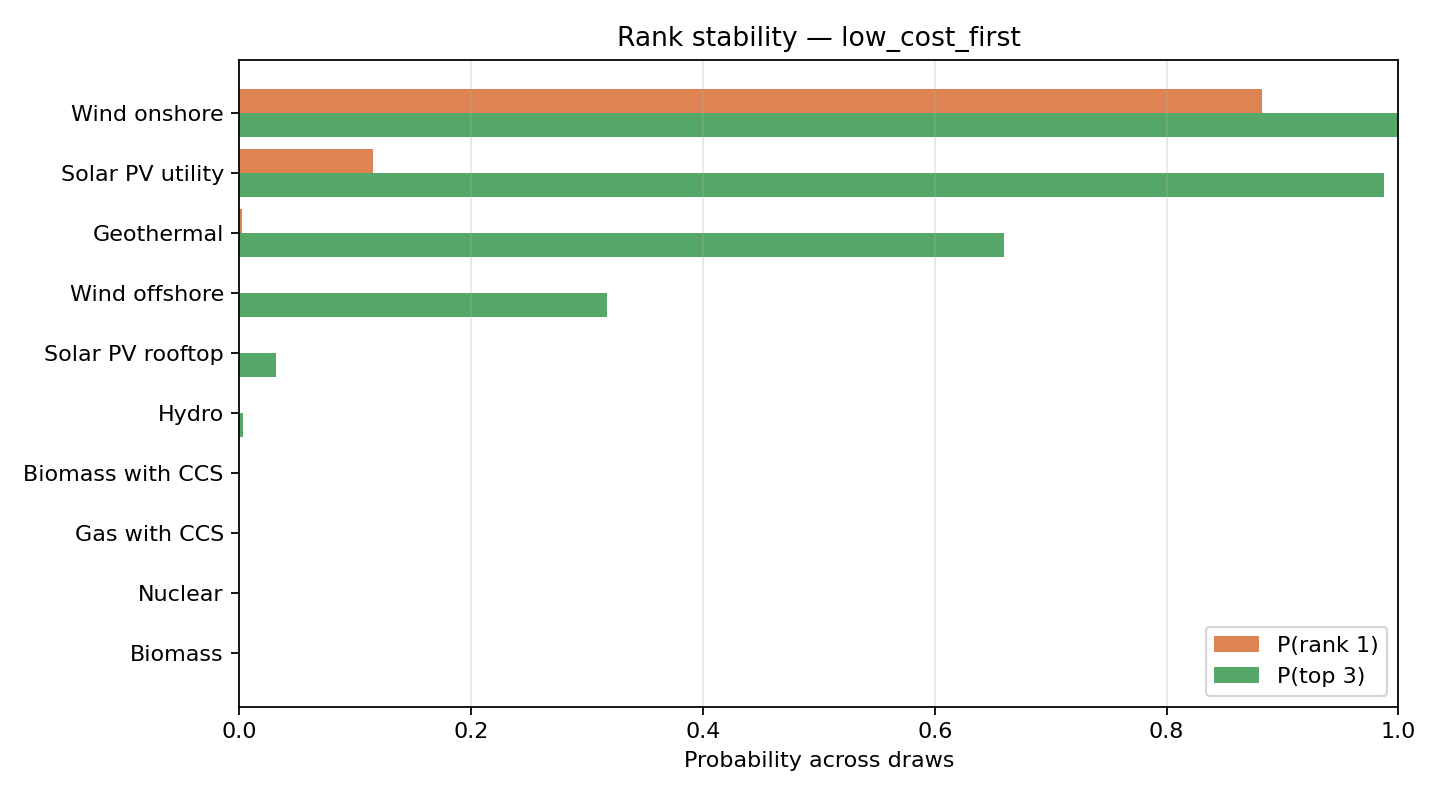

In [10]:
for scenario in ['high_reliability_first', 'low_cost_first']:
    mc = scenario_results[scenario]
    score_png = figures_dir / f'scores_{scenario}.png'
    rank_png = figures_dir / f'rank_stability_{scenario}.png'
    plot_scenario_scores(mc['score_summary'], score_png, title=f'Scores — {scenario}')
    plot_rank_stability(mc['rank_stability'], rank_png, title=f'Rank stability — {scenario}')
    display(Image(filename=str(score_png)))
    display(Image(filename=str(rank_png)))

### Structured report

All of the above is assembled into a single versioned JSON document that a dashboard or API can consume without re-running the analysis (schema in [`../docs/report_schema.json`](../docs/report_schema.json)).

In [11]:
report = build_report(
    dataset_schema_version='1.0',
    seed=SEED,
    samples=SAMPLES,
    scenarios={
        name: {
            'weights': SCENARIOS[name],
            'score_summary': result['score_summary'],
            'rank_stability': result['rank_stability'],
        }
        for name, result in scenario_results.items()
    },
    pareto_frontier=frontier,
    best_by_metric=best_by_metric,
)
validate_report(report)
{'top_level_keys': sorted(report), 'scenarios': sorted(report['scenarios']), 'method': report['method']}

{'top_level_keys': ['best_by_metric',
  'dataset_schema_version',
  'method',
  'pareto_frontier',
  'report_schema_version',
  'scenarios'],
 'scenarios': ['balanced',
  'high_reliability_first',
  'low_cost_first',
  'low_emissions_first'],
 'method': {'normalization': 'minmax_cleaner_is_higher',
  'uncertainty': 'triangular(low, central, high) Monte Carlo',
  'samples': 2000,
  'seed': 42}}

## 3. Region & deployment context

Cleanliness is not only a property of a technology — it depends on *where* and *when* it is built. This part adds three context dimensions.

### 3a. Multi-region counterfactuals

For each region config under [`../data/regions/`](../data/regions/) we ask: if one source is retired and its energy is absorbed by an alternative, how do annual lifecycle emissions (ktCO2e/year) change? Total generation is conserved.

In [12]:
regions_table = run_region_scenarios(PROJECT_ROOT / 'data' / 'regions')
moves = regions_table[regions_table['replacement'] != '']
moves[['region', 'scenario', 'moved_twh', 'annual_ktco2e', 'delta_ktco2e', 'pct_change']].reset_index(drop=True)

,region,scenario,moved_twh,annual_ktco2e,delta_ktco2e,pct_change
0,France,Retire Nuclear -> Wind,320.0,22847.6,-320.0,-1.4
1,France,Retire Nuclear -> Solar,320.0,34687.6,11520.0,49.7
2,France,Retire Nuclear -> Hydro,320.0,27007.6,3840.0,16.6
3,France,Retire Nuclear -> Gas,320.0,176127.6,152960.0,660.2
4,Germany,Retire Lignite+Coal -> Wind,113.7,38302.1,-113711.3,-74.8
5,Germany,Retire Lignite+Coal -> Solar,113.7,42509.0,-109504.4,-72.0
6,Germany,Retire Lignite+Coal -> Nuclear,113.7,38415.8,-113597.6,-74.7
7,Germany,Retire Lignite+Coal -> Gas,113.7,92764.4,-59249.0,-39.0
8,Portugal,Retire Gas -> Wind,10.0,1419.8,-4790.0,-77.1
9,Portugal,Retire Gas -> Solar,10.0,1789.8,-4420.0,-71.2


Replacing a low-carbon source with **gas** raises emissions sharply (France: retiring nuclear for gas is far worse than for wind), while in coal-heavy Germany any clean replacement slashes emissions — and nuclear and wind land within a hair of each other.

### 3b. Region-aware financing (cost of capital)

Levelized cost depends heavily on the cost of capital. Capital-intensive low-carbon options (nuclear, hydro, offshore wind) are penalised most by a high WACC; fuel-heavy gas is barely affected. So a region's financing environment changes which clean option is cheapest.

In [13]:
financing = pd.concat([lcoe_table(env) for env in DEFAULT_ENVIRONMENTS.values()], ignore_index=True)
lcoe_by_env = financing.pivot(index='technology', columns='environment', values='lcoe_usd_mwh')
lcoe_by_env = lcoe_by_env.sort_values(lcoe_by_env.columns[0])
lcoe_by_env

environment,High risk (emerging/unstable policy),Low risk (stable OECD),Medium risk
technology,,,
Wind onshore,55.4,34.4,39.8
Solar PV utility,61.5,33.8,40.9
Gas,72.4,59.8,63.0
Hydro,86.3,35.3,49.0
Geothermal,89.9,53.6,62.9
Nuclear,108.2,55.3,69.0
Gas with CCS,114.1,87.8,94.5
Wind offshore,120.6,73.8,85.8


In [14]:
# How much each technology's LCOE rises from a low (3%) to a high (10%) cost of capital.
wacc_sensitivity()

,technology,lcoe_at_3pct,lcoe_at_10pct,pct_increase
0,Hydro,35.3,86.3,144.1
1,Nuclear,55.3,108.2,95.7
2,Solar PV utility,33.8,61.5,81.7
3,Geothermal,53.6,89.9,67.6
4,Wind offshore,73.8,120.6,63.4
5,Wind onshore,34.4,55.4,61.3
6,Gas with CCS,87.8,114.1,29.9
7,Gas,59.8,72.4,21.0


Nuclear is competitive with renewables **only** at a low cost of capital: its LCOE roughly doubles from ~3% to ~10% WACC, while gas barely moves. This is why nuclear economics are so sensitive to financing and policy stability.

### 3c. Geography, grid context and deployment year

A clean build's *value* is the carbon it avoids = the grid intensity it displaces minus its own lifecycle intensity. That depends on geography, what the grid is made of, and the deployment year as grids decarbonise.

In [15]:
grid = load_grid_intensity(PROJECT_ROOT / 'data' / 'grid_carbon_intensity.csv')
trajectory_table(grid)

,region,year,grid_gco2_kwh,pct_change_from_first
0,EU,2015,330.0,0.0
1,EU,2018,300.0,-9.1
2,EU,2020,250.0,-24.2
3,EU,2023,242.0,-26.7
4,France,2015,52.0,0.0
5,France,2018,58.0,11.5
6,France,2020,52.0,0.0
7,France,2023,56.0,7.7
8,Germany,2015,470.0,0.0
9,Germany,2018,440.0,-6.4


In [16]:
clean_lifecycle = {
    tech: float(wide.loc[wide['technology'] == tech, 'lifecycle_co2e'].iloc[0])
    for tech in ['Nuclear', 'Wind onshore', 'Solar PV utility', 'Hydro']
}
abatement = abatement_table(clean_lifecycle, ['France', 'Germany', 'Portugal', 'EU'], [2015, 2023], grid)
abatement.pivot_table(index=['region', 'year'], columns='technology', values='abatement_gco2_kwh')

technology     Hydro  Nuclear  Solar PV utility  Wind onshore
region   year                                                
EU       2015  306.0    318.0             282.0         319.0
         2023  218.0    230.0             194.0         231.0
France   2015   28.0     40.0               4.0          41.0
         2023   32.0     44.0               8.0          45.0
Germany  2015  446.0    458.0             422.0         459.0
         2023  347.0    359.0             323.0         360.0
Portugal 2015  216.0    228.0             192.0         229.0
         2023  101.0    113.0              77.0         114.0

The same new nuclear plant avoids ~359 gCO2/kWh in Germany's coal-heavy grid but only ~44 in France's already-clean grid, and Portugal's benefit fell from ~228 (2015) to ~113 (2023) as its grid decarbonised. Geography, grid context and deployment year all change the answer.

## Conclusion

- On lifecycle **carbon**, the broad claim is wrong as written: onshore wind has a lower IPCC median than nuclear, offshore wind is tied, and the uncertainty ranges overlap.
- Across **ten technologies and twelve metrics** there is no universal winner. The leader flips with the policy intent: reliability-first favours dispatchable geothermal and nuclear; cost-first and emissions-first favour wind, solar and geothermal. Rank-stability percentages and overlapping intervals show single-number rankings overstate certainty.
- In **context**, value is conditional: nuclear is cheap only at a low cost of capital, and a clean build avoids far more carbon in a dirty grid than a clean one — and less as grids decarbonise.

> Nuclear, wind and solar are all low-carbon electricity sources. Nuclear is often lower-carbon than solar PV and is highly reliable, but it is not clearly cleaner than wind, and which option is “cleanest” depends on the metric, the weighting, the region and the year.